In [1]:
#!/usr/bin/env python3
import pandas as pd

# Load your combined SCCmec results
df = pd.read_csv('all_samples_combined.csv')

# Define genome ID ranges for each country
def get_country(sample_id):
    """Determine the country based on sample ID ranges"""
    # Extract the numeric part
    if sample_id.startswith('ERR'):
        num = int(sample_id[3:])
    elif sample_id.startswith('SRR'):
        num = int(sample_id[3:])
    else:
        return 'Unknown'
    
    # Uganda: ERR4692235 to ERR4692276 and SRR31799955 to SRR31800733
    if (sample_id.startswith('ERR') and 4692235 <= num <= 4692276) or \
       (sample_id.startswith('SRR') and 31799955 <= num <= 31800733):
        return 'Uganda'
    
    # Kenya: ERR3150908 to ERR3151001, ERR3218227, ERR1764887 to ERR1765052, 
    # ERR1791869 to ERR1791882 and ERR2436451 to ERR2436455
    elif (sample_id.startswith('ERR') and (
            (3150908 <= num <= 3151001) or
            num == 3218227 or
            (1764887 <= num <= 1765052) or
            (1791869 <= num <= 1791882) or
            (2436451 <= num <= 2436455))):
        return 'Kenya'
    
    # Tanzania: ERR12916291 to ERR12916300 and ERR12511686 to ERR12511850
    elif (sample_id.startswith('ERR') and (
            (12916291 <= num <= 12916300) or
            (12511686 <= num <= 12511850))):
        return 'Tanzania'
    
    else:
        return 'Unknown'

# Apply the function to add country column
df['country'] = df['sample'].apply(get_country)

# Create a more organized summary with key columns
summary_cols = ['sample', 'country', 'type', 'subtype', 'mecA', 'targets', 'regions', 'coverage', 'hits', 'comment']
summary_df = df[summary_cols].copy()

# Save the enhanced results
df.to_csv('all_samples_with_metadata.csv', index=False)
summary_df.to_csv('sccmec_summary_with_metadata.csv', index=False)

# Create a pivot table for better visualization
pivot_table = pd.pivot_table(
    df,
    index=['country', 'type'],
    values=['sample'],
    aggfunc='count',
    fill_value=0
).rename(columns={'sample': 'count'})

# Save pivot table
pivot_table.to_csv('sccmec_by_country_and_type.csv')

print("Data analysis complete!")
print(f"Total samples processed: {len(df)}")
print("\nCountry distribution:")
print(df['country'].value_counts())
print("\nSCCmec type distribution:")
print(df['type'].value_counts())
print("\nMRSA (mecA+) distribution:")
print(df['mecA'].value_counts())

# Print some summary statistics
print(f"\nSamples with identifiable SCCmec types: {(df['type'] != '-').sum()}")
print(f"Samples with mecA+: {(df['mecA'] == '+').sum()}")
print(f"Samples with mecA-: {(df['mecA'] == '-').sum()}")

print("\nFiles created:")
print("1. all_samples_with_metadata.csv - Full dataset with country metadata")
print("2. sccmec_summary_with_metadata.csv - Simplified summary with key columns")
print("3. sccmec_by_country_and_type.csv - Pivot table of counts by country and SCCmec type")

Data analysis complete!
Total samples processed: 313

Country distribution:
country
Kenya       171
Tanzania    124
Uganda       18
Name: count, dtype: int64

SCCmec type distribution:
type
-      277
V       29
IV       5
III      2
Name: count, dtype: int64

MRSA (mecA+) distribution:
mecA
-    248
+     65
Name: count, dtype: int64

Samples with identifiable SCCmec types: 36
Samples with mecA+: 65
Samples with mecA-: 248

Files created:
1. all_samples_with_metadata.csv - Full dataset with country metadata
2. sccmec_summary_with_metadata.csv - Simplified summary with key columns
3. sccmec_by_country_and_type.csv - Pivot table of counts by country and SCCmec type


In [4]:
#!/usr/bin/env python3
import pandas as pd
from tabulate import tabulate

# Load your data
df = pd.read_csv('all_samples_combined.csv')

# Add country column (using the same function as above)
def get_country(sample_id):
    if sample_id.startswith('ERR'):
        num = int(sample_id[3:])
    elif sample_id.startswith('SRR'):
        num = int(sample_id[3:])
    else:
        return 'Unknown'
    
    # Uganda
    if (sample_id.startswith('ERR') and 4692235 <= num <= 4692276) or \
       (sample_id.startswith('SRR') and 31799955 <= num <= 31800733):
        return 'Uganda'
    
    # Kenya
    elif (sample_id.startswith('ERR') and (
            (3150908 <= num <= 3151001) or
            num == 3218227 or
            (1764887 <= num <= 1765052) or
            (1791869 <= num <= 1791882) or
            (2436451 <= num <= 2436455))):
        return 'Kenya'
    
    # Tanzania
    elif (sample_id.startswith('ERR') and (
            (12916291 <= num <= 12916300) or
            (12511686 <= num <= 12511850))):
        return 'Tanzania'
    
    else:
        return 'Unknown'

df['country'] = df['sample'].apply(get_country)

# Create detailed summary tables
print("=" * 80)
print("SCCmEC TYPE ANALYSIS BY COUNTRY")
print("=" * 80)

# 1. Overall summary by country
print("\n1. SAMPLE DISTRIBUTION BY COUNTRY:")
print("-" * 40)
country_summary = df['country'].value_counts().reset_index()
country_summary.columns = ['Country', 'Sample Count']
print(tabulate(country_summary, headers='keys', tablefmt='grid', showindex=False))

# 2. SCCmec type distribution by country
print("\n2. SCCmEC TYPE DISTRIBUTION BY COUNTRY:")
print("-" * 40)
type_by_country = pd.crosstab(df['country'], df['type'], margins=True, margins_name="Total")
print(tabulate(type_by_country, headers='keys', tablefmt='grid'))

# 3. mecA status by country
print("\n3. mecA STATUS BY COUNTRY:")
print("-" * 40)
mecA_by_country = pd.crosstab(df['country'], df['mecA'], margins=True, margins_name="Total")
print(tabulate(mecA_by_country, headers='keys', tablefmt='grid'))

# 4. Detailed breakdown for identified SCCmec types
print("\n4. DETAILED SCCmEC TYPE BREAKDOWN:")
print("-" * 40)
identified = df[df['type'] != '-']
if not identified.empty:
    type_details = identified.groupby(['country', 'type', 'subtype']).agg({
        'sample': 'count',
        'mecA': lambda x: (x == '+').sum(),
        'coverage': 'mean',
        'hits': 'mean'
    }).round(2)
    type_details.columns = ['Sample Count', 'mecA+ Count', 'Avg Coverage', 'Avg Hits']
    print(tabulate(type_details.reset_index(), headers='keys', tablefmt='grid', showindex=False))
else:
    print("No identifiable SCCmec types found.")

# 5. Samples with partial SCCmec elements
print("\n5. SAMPLES WITH PARTIAL SCCmEC ELEMENTS (mecA+ but no type):")
print("-" * 40)
partial = df[(df['type'] == '-') & (df['mecA'] == '+')]
if not partial.empty:
    partial_summary = partial.groupby('country').agg({
        'sample': 'count',
        'targets': lambda x: ', '.join(sorted(set([str(i) for i in x if pd.notna(i)])))
    })
    partial_summary.columns = ['Sample Count', 'Common Targets Found']
    print(tabulate(partial_summary.reset_index(), headers='keys', tablefmt='grid', showindex=False))
else:
    print("No samples with mecA+ but no SCCmec type identified.")

# 6. Most common target combinations
print("\n6. MOST COMMON TARGET COMBINATIONS:")
print("-" * 40)
target_summary = df['targets'].value_counts().head(10).reset_index()
target_summary.columns = ['Target Combination', 'Count']
print(tabulate(target_summary, headers='keys', tablefmt='grid', showindex=False))

# Save all analyses to files
df.to_csv('all_samples_country_metadata.csv', index=False)

# Create a country-specific summary
for country in df['country'].unique():
    country_df = df[df['country'] == country]
    if not country_df.empty:
        filename = f"sccmec_{country.lower()}_summary.csv"
        country_df.to_csv(filename, index=False)
        print(f"\nSaved {len(country_df)} samples from {country} to {filename}")

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE!")
print("=" * 80)

SCCmEC TYPE ANALYSIS BY COUNTRY

1. SAMPLE DISTRIBUTION BY COUNTRY:
----------------------------------------
+-----------+----------------+
| Country   |   Sample Count |
+===========+================+
| Kenya     |            171 |
+-----------+----------------+
| Tanzania  |            124 |
+-----------+----------------+
| Uganda    |             18 |
+-----------+----------------+

2. SCCmEC TYPE DISTRIBUTION BY COUNTRY:
----------------------------------------
+-----------+-----+-------+------+-----+---------+
| country   |   - |   III |   IV |   V |   Total |
+===========+=====+=======+======+=====+=========+
| Kenya     | 166 |     1 |    4 |   0 |     171 |
+-----------+-----+-------+------+-----+---------+
| Tanzania  |  95 |     0 |    1 |  28 |     124 |
+-----------+-----+-------+------+-----+---------+
| Uganda    |  16 |     1 |    0 |   1 |      18 |
+-----------+-----+-------+------+-----+---------+
| Total     | 277 |     2 |    5 |  29 |     313 |
+-----------+-----+-

SCCmEC TYPING ANALYSIS FOR EAST AFRICAN S. AUREUS
Loading data...
Data loaded: 313 samples
Countries: {'Kenya': 171, 'Tanzania': 124, 'Uganda': 18}
Extracting genetic elements...
Genetic elements extracted successfully

STATISTICAL ANALYSIS RESULTS

1. SCCmEC TYPE DISTRIBUTION BY COUNTRY (Chi-square test)
------------------------------------------------------------
Chi-square statistic: 52.2130
p-value: 1.6897e-09
Degrees of freedom: 6

2. mecA PREVALENCE BY COUNTRY (Fisher's exact test)
------------------------------------------------------------
Odds ratio: 0.0354
Fisher's exact p-value: 2.8373e-20

3. IS ELEMENT PREVALENCE COMPARISONS (Chi-square tests)
------------------------------------------------------------

IS1272:
  Kenya: 14.04% (24/171)
  Tanzania: 44.35% (55/124)
  Uganda: 5.56% (1/18)
  Kenya vs Tanzania: p = 1.4126e-08 ***
  Kenya vs Uganda: p = 5.1935e-01 ns
  Tanzania vs Uganda: p = 3.8587e-03 **

IS431:
  Kenya: 0.00% (0/171)
  Tanzania: 0.00% (0/124)
  Uganda: 0.00%

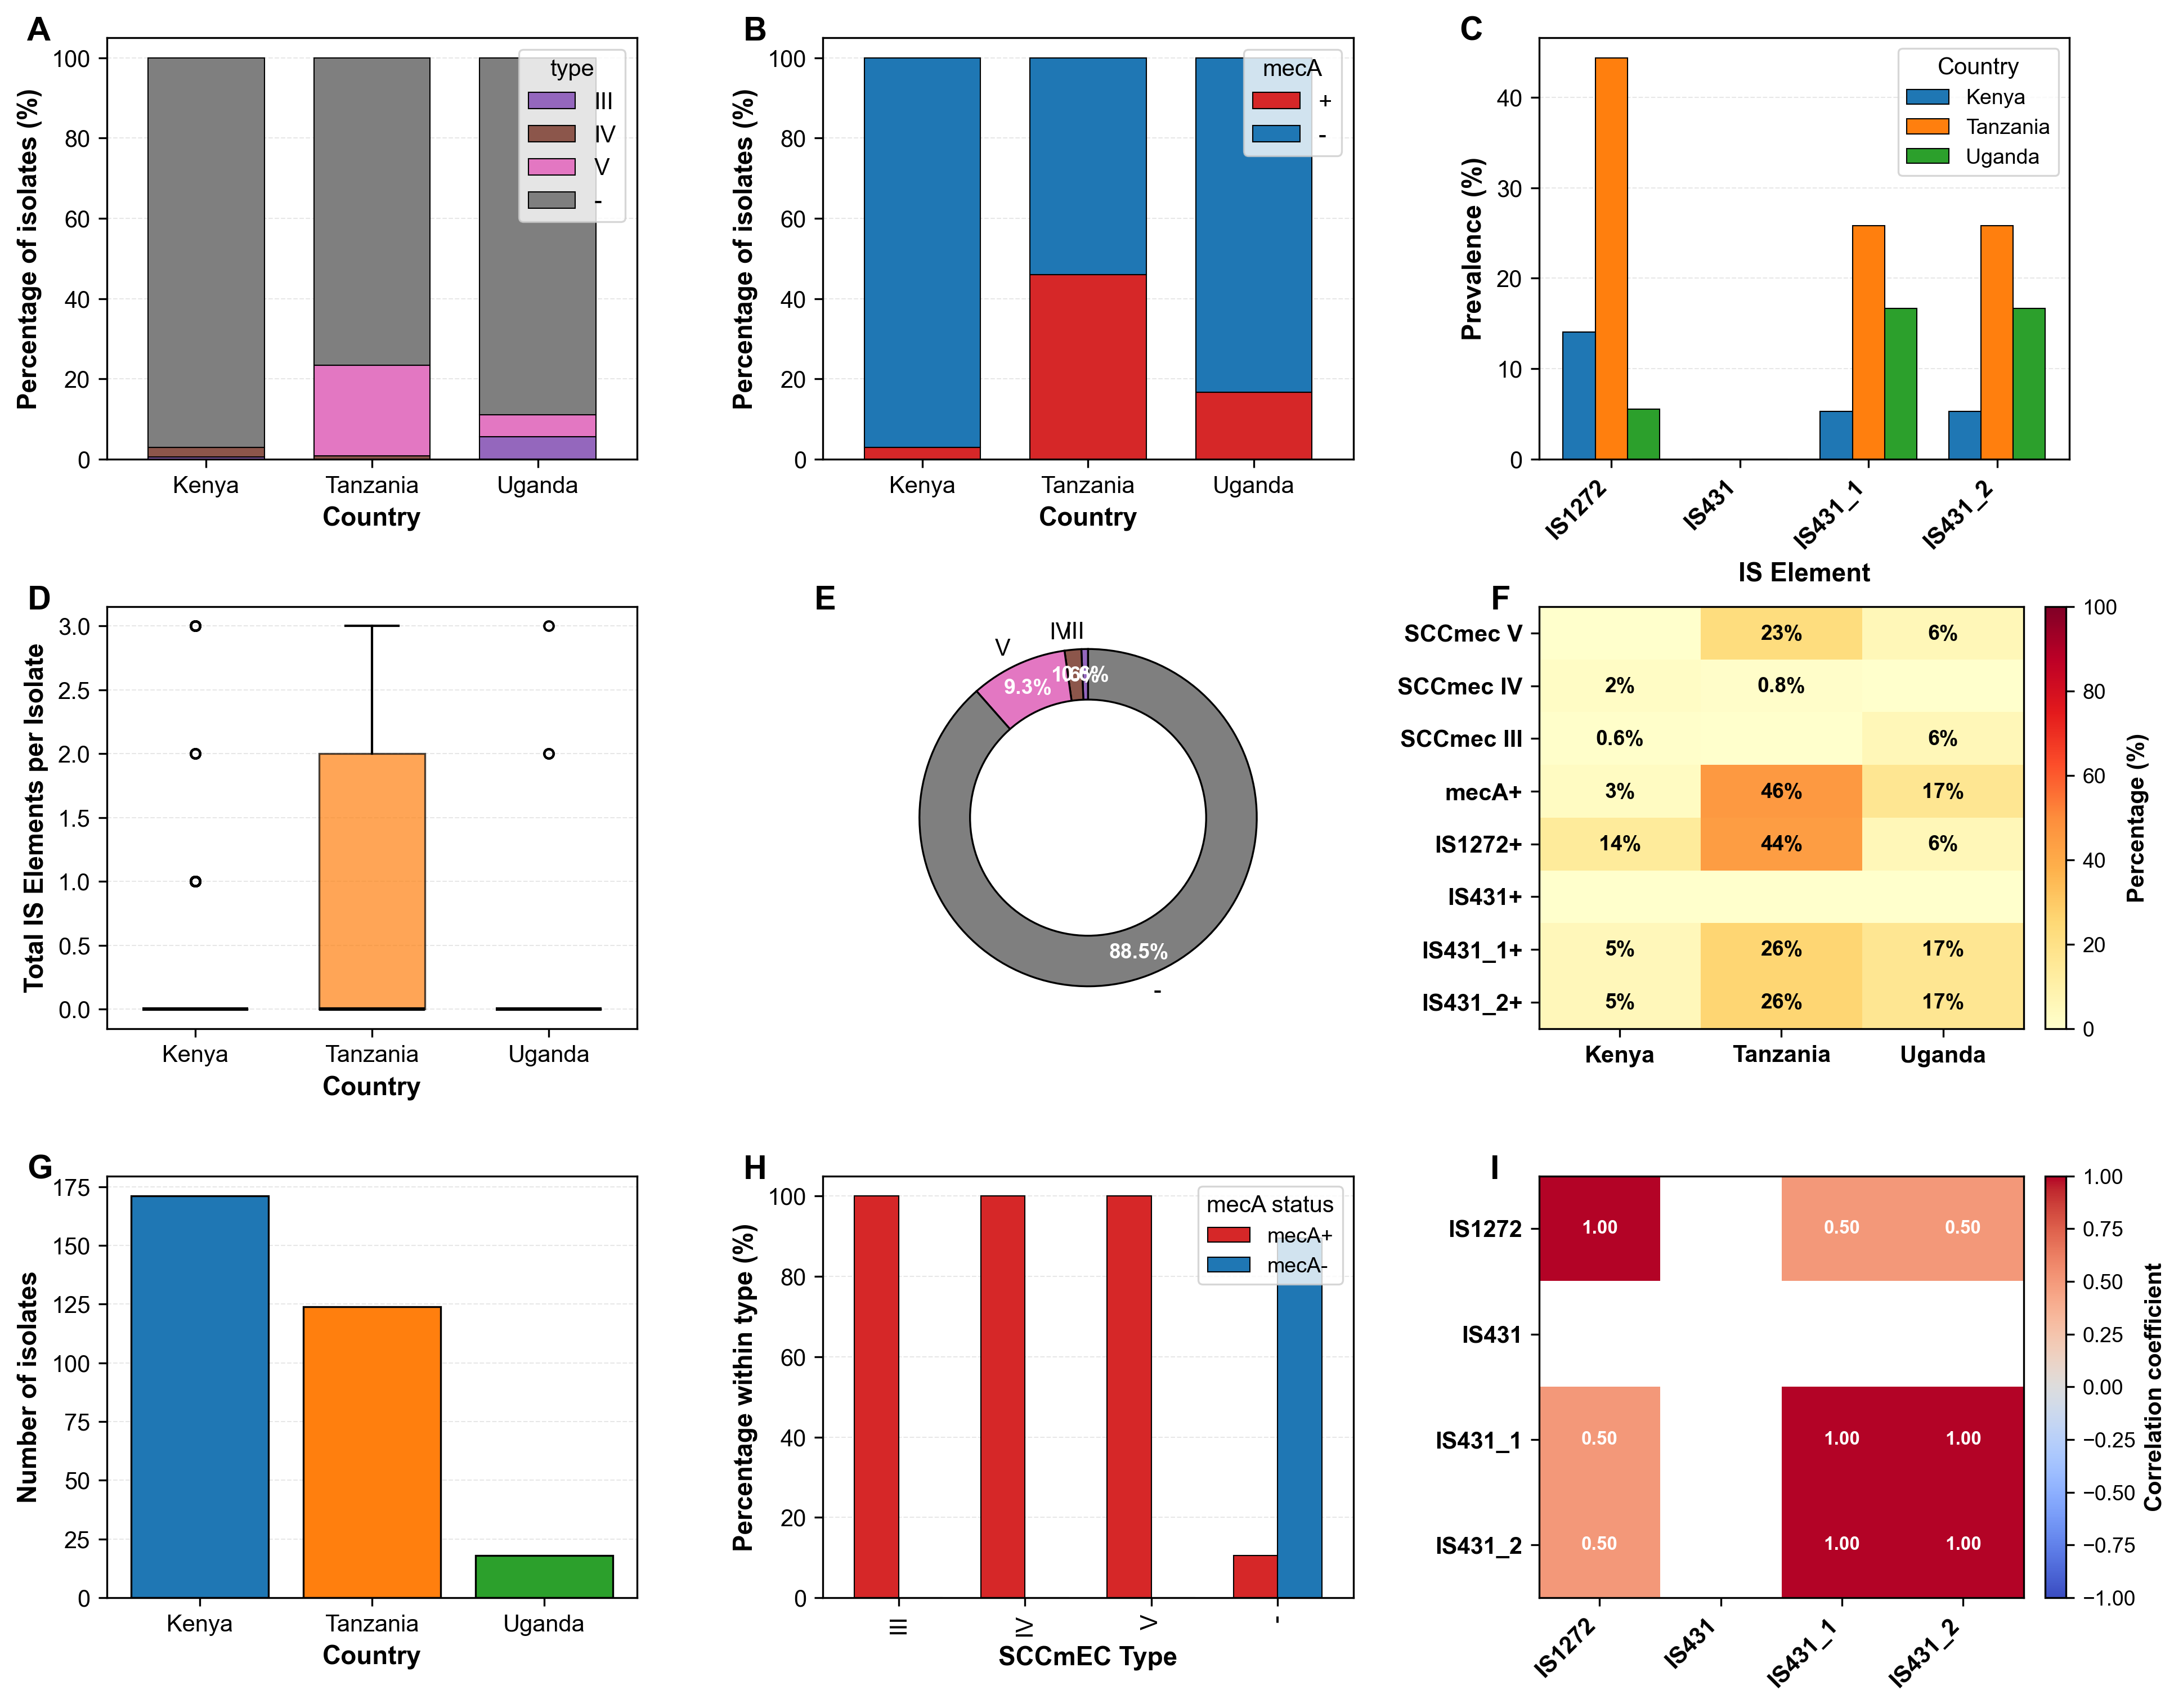


Enhanced dataset saved: SCCmEC_data_with_metadata_and_elements.csv
Figure legend saved: Figure_Legend.txt
Results section text saved: Results_Section_SCCmEC.txt
Summary statistics saved: Summary_Statistics_SCCmEC.csv
Statistical report saved: Statistical_Report_SCCmEC.txt

ANALYSIS COMPLETE

Generated files:
1. Figure_SCCmEC_East_Africa.[tiff/pdf/png] - Multi-panel figure
2. Figure_Legend.txt - Complete figure legend
3. Results_Section_SCCmEC.txt - Results section for manuscript
4. Summary_Statistics_SCCmEC.csv - Summary statistics table
5. Statistical_Report_SCCmEC.txt - Detailed statistical report
6. SCCmEC_data_with_metadata_and_elements.csv - Enhanced dataset

KEY FINDINGS SUMMARY

Total isolates analyzed: 313
Kenya: 171 (54.6%)
Tanzania: 124 (39.6%)
Uganda: 18 (5.8%)

mecA+ isolates: 65 (20.8%)
SCCmec type V: 29 (9.3%)
SCCmec type IV: 5 (1.6%)
SCCmec type III: 2 (0.6%)
Untypable: 277 (88.5%)

IS1272 prevalence: 80 (25.6%)

READY FOR MANUSCRIPT SUBMISSION


In [8]:
#!/usr/bin/env python3
"""
SCCmEC Statistical Analysis and Publication-Ready Visualization
For manuscript: Comparative SCCmEC typing of S. aureus from East Africa
Author: Bioinformatics Analysis Pipeline
Version: 1.0
Date: Generated for Manuscript Submission
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu, kruskal
import warnings
import os

warnings.filterwarnings('ignore')

# ============================================================================
# SETUP AND DATA LOADING
# ============================================================================

def setup_plotting_style():
    """Configure publication-quality plotting style"""
    plt.rcParams.update({
        'font.size': 10,
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial'],
        'axes.labelsize': 11,
        'axes.titlesize': 12,
        'legend.fontsize': 10,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'figure.dpi': 300,
        'savefig.dpi': 600,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.1,
        'axes.linewidth': 0.8,
        'grid.linewidth': 0.5,
        'lines.linewidth': 1.5,
        'patch.linewidth': 0.8,
        'hatch.linewidth': 0.5
    })

def load_and_preprocess_data():
    """Load SCCmEC data and add metadata"""
    print("Loading data...")
    
    # Load the combined data
    df = pd.read_csv('all_samples_combined.csv')
    
    # Add country metadata
    def get_country(sample_id):
        """Determine the country based on sample ID ranges"""
        if sample_id.startswith('ERR'):
            try:
                num = int(sample_id[3:])
            except:
                return 'Unknown'
        elif sample_id.startswith('SRR'):
            try:
                num = int(sample_id[3:])
            except:
                return 'Unknown'
        else:
            return 'Unknown'
        
        # Uganda: ERR4692235 to ERR4692276 and SRR31799955 to SRR31800733
        if (sample_id.startswith('ERR') and 4692235 <= num <= 4692276) or \
           (sample_id.startswith('SRR') and 31799955 <= num <= 31800733):
            return 'Uganda'
        
        # Kenya: ERR3150908 to ERR3151001, ERR3218227, ERR1764887 to ERR1765052, 
        # ERR1791869 to ERR1791882 and ERR2436451 to ERR2436455
        elif (sample_id.startswith('ERR') and (
                (3150908 <= num <= 3151001) or
                num == 3218227 or
                (1764887 <= num <= 1765052) or
                (1791869 <= num <= 1791882) or
                (2436451 <= num <= 2436455))):
            return 'Kenya'
        
        # Tanzania: ERR12916291 to ERR12916300 and ERR12511686 to ERR12511850
        elif (sample_id.startswith('ERR') and (
                (12916291 <= num <= 12916300) or
                (12511686 <= num <= 12511850))):
            return 'Tanzania'
        
        else:
            return 'Unknown'
    
    df['country'] = df['sample'].apply(get_country)
    print(f"Data loaded: {len(df)} samples")
    print(f"Countries: {df['country'].value_counts().to_dict()}")
    
    return df

def extract_genetic_elements(df):
    """Extract IS elements and ccr genes from targets column"""
    print("Extracting genetic elements...")
    
    # Function to extract IS elements
    def extract_is_elements(targets):
        if pd.isna(targets) or targets == '':
            return {'IS1272': 0, 'IS431': 0, 'IS431_1': 0, 'IS431_2': 0, 'total_IS': 0, 'any_IS431': 0}
        
        if isinstance(targets, str):
            targets_list = targets.split(',')
        else:
            targets_list = []
        
        is_counts = {
            'IS1272': 1 if 'IS1272' in targets_list else 0,
            'IS431': 1 if 'IS431' in targets_list and 'IS431_1' not in targets_list and 'IS431_2' not in targets_list else 0,
            'IS431_1': 1 if 'IS431_1' in targets_list else 0,
            'IS431_2': 1 if 'IS431_2' in targets_list else 0
        }
        
        # Check for any IS431 variant (including base IS431)
        is431_variants = ['IS431', 'IS431_1', 'IS431_2']
        is_counts['any_IS431'] = 1 if any(var in targets_list for var in is431_variants) else 0
        is_counts['total_IS'] = sum(is_counts[el] for el in ['IS1272', 'IS431', 'IS431_1', 'IS431_2'])
        
        return is_counts
    
    # Function to extract ccr genes
    def extract_ccr_genes(targets):
        if pd.isna(targets) or targets == '':
            return {'ccrA': 0, 'ccrB': 0, 'ccrC': 0, 'total_ccr': 0}
        
        if isinstance(targets, str):
            targets_list = targets.split(',')
        else:
            targets_list = []
        
        ccr_counts = {
            'ccrA': 1 if any(x in targets_list for x in ['ccrA', 'ccrA2', 'ccrA3']) else 0,
            'ccrB': 1 if any(x in targets_list for x in ['ccrB', 'ccrB2', 'ccrB3']) else 0,
            'ccrC': 1 if 'ccrC' in targets_list or 'ccrC1' in targets_list else 0
        }
        
        ccr_counts['total_ccr'] = sum(ccr_counts.values())
        return ccr_counts
    
    # Apply extraction functions
    is_data = df['targets'].apply(extract_is_elements)
    is_df = pd.DataFrame(is_data.tolist(), index=df.index)
    
    ccr_data = df['targets'].apply(extract_ccr_genes)
    ccr_df = pd.DataFrame(ccr_data.tolist(), index=df.index)
    
    # Combine with original dataframe
    df_combined = pd.concat([df, is_df, ccr_df], axis=1)
    
    # Clean up the type and subtype columns
    df_combined['type'] = df_combined['type'].fillna('-')
    df_combined['subtype'] = df_combined['subtype'].fillna('-')
    
    print("Genetic elements extracted successfully")
    return df_combined

# ============================================================================
# STATISTICAL ANALYSIS
# ============================================================================

def perform_statistical_analysis(df):
    """Perform comprehensive statistical analysis"""
    print("\n" + "=" * 80)
    print("STATISTICAL ANALYSIS RESULTS")
    print("=" * 80)
    
    results = {}
    
    # 1. Chi-square test for SCCmec type distribution
    print("\n1. SCCmEC TYPE DISTRIBUTION BY COUNTRY (Chi-square test)")
    print("-" * 60)
    type_country_table = pd.crosstab(df['country'], df['type'])
    
    # Check if table is valid for chi-square test
    if type_country_table.size > 0 and type_country_table.sum().sum() > 0:
        try:
            chi2, p_type, dof, expected = chi2_contingency(type_country_table)
            results['chi2_type'] = chi2
            results['p_type'] = p_type
            results['dof_type'] = dof
            print(f"Chi-square statistic: {chi2:.4f}")
            print(f"p-value: {p_type:.4e}")
            print(f"Degrees of freedom: {dof}")
        except Exception as e:
            print(f"Error in chi-square test: {str(e)}")
            results['chi2_type'] = np.nan
            results['p_type'] = np.nan
            results['dof_type'] = np.nan
    else:
        print("Insufficient data for chi-square test")
        results['chi2_type'] = np.nan
        results['p_type'] = np.nan
        results['dof_type'] = np.nan
    
    # 2. Fisher's exact test for mecA prevalence
    print("\n2. mecA PREVALENCE BY COUNTRY (Fisher's exact test)")
    print("-" * 60)
    meca_country_table = pd.crosstab(df['country'], df['mecA'])
    
    # Check if table is 2x2 for Fisher's exact test
    if meca_country_table.shape == (2, 2) or (meca_country_table.shape[0] == 3 and meca_country_table.shape[1] == 2):
        try:
            # For 3x2 table, take the two most relevant countries or aggregate
            if meca_country_table.shape[0] == 3:
                # Use Kenya and Tanzania for comparison
                if 'Kenya' in meca_country_table.index and 'Tanzania' in meca_country_table.index:
                    subtable = meca_country_table.loc[['Kenya', 'Tanzania']]
                    odds_ratio, p_fisher = fisher_exact(subtable)
                else:
                    odds_ratio, p_fisher = np.nan, np.nan
            else:
                odds_ratio, p_fisher = fisher_exact(meca_country_table)
            
            results['odds_ratio'] = odds_ratio
            results['p_fisher'] = p_fisher
            print(f"Odds ratio: {odds_ratio:.4f}")
            print(f"Fisher's exact p-value: {p_fisher:.4e}")
        except Exception as e:
            print(f"Error in Fisher's exact test: {str(e)}")
            results['odds_ratio'] = np.nan
            results['p_fisher'] = np.nan
    else:
        print("Table not 2x2, cannot perform Fisher's exact test")
        results['odds_ratio'] = np.nan
        results['p_fisher'] = np.nan
    
    # 3. IS element prevalence comparisons
    print("\n3. IS ELEMENT PREVALENCE COMPARISONS (Chi-square tests)")
    print("-" * 60)
    
    country_pairs = [('Kenya', 'Tanzania'), ('Kenya', 'Uganda'), ('Tanzania', 'Uganda')]
    is_elements = ['IS1272', 'IS431', 'IS431_1', 'IS431_2', 'any_IS431', 'total_IS']
    
    results['is_prevalence'] = {}
    results['pairwise_is'] = {}
    
    for is_element in is_elements:
        if is_element not in df.columns:
            continue
            
        print(f"\n{is_element}:")
        is_present = df.groupby('country')[is_element].apply(lambda x: (x > 0).sum())
        is_total = df.groupby('country')[is_element].count()
        is_prevalence = (is_present / is_total * 100)
        
        # Store as rounded values in dictionary
        results['is_prevalence'][is_element] = {k: round(v, 2) for k, v in is_prevalence.to_dict().items()}
        
        for country in ['Kenya', 'Tanzania', 'Uganda']:
            if country in is_prevalence.index:
                prev_value = is_prevalence[country]
                count_value = is_present[country]
                total_value = is_total[country]
                print(f"  {country}: {prev_value:.2f}% ({count_value}/{total_value})")
        
        # Pairwise chi-square tests
        results['pairwise_is'][is_element] = {}
        for country1, country2 in country_pairs:
            subset = df[df['country'].isin([country1, country2])]
            if len(subset) > 0 and country1 in df['country'].values and country2 in df['country'].values:
                contingency = pd.crosstab(subset['country'], subset[is_element] > 0)
                if contingency.shape == (2, 2) and contingency.sum().min() > 0:
                    try:
                        chi2_is, p_is, _, _ = chi2_contingency(contingency)
                        if p_is < 0.05:
                            sig = "***" if p_is < 0.001 else "**" if p_is < 0.01 else "*"
                        else:
                            sig = "ns"
                        results['pairwise_is'][is_element][f"{country1}_vs_{country2}"] = {
                            'chi2': chi2_is, 'p': p_is, 'sig': sig
                        }
                        print(f"  {country1} vs {country2}: p = {p_is:.4e} {sig}")
                    except Exception as e:
                        print(f"  {country1} vs {country2}: Error in chi-square test")
                        results['pairwise_is'][is_element][f"{country1}_vs_{country2}"] = {
                            'chi2': np.nan, 'p': np.nan, 'sig': 'error'
                        }
                else:
                    print(f"  {country1} vs {country2}: Insufficient data for chi-square test")
    
    # 4. Kruskal-Wallis test for IS element counts (with error handling)
    print("\n4. IS ELEMENT COUNTS BY COUNTRY (Kruskal-Wallis test)")
    print("-" * 60)
    
    results['kruskal'] = {}
    
    for is_element in ['total_IS', 'IS1272', 'IS431', 'IS431_1', 'IS431_2']:
        if is_element not in df.columns:
            continue
            
        print(f"\n{is_element}:")
        
        # Check if there's variation in the data
        groups = []
        country_labels = []
        for c in ['Kenya', 'Tanzania', 'Uganda']:
            if c in df['country'].unique():
                group_data = df[df['country'] == c][is_element].dropna().values
                if len(group_data) > 0:
                    groups.append(group_data)
                    country_labels.append(c)
        
        if len(groups) >= 2 and all(len(g) > 0 for g in groups):
            try:
                # Check if all values are identical
                all_values = np.concatenate(groups)
                if len(np.unique(all_values)) > 1:
                    h_stat, p_kw = kruskal(*groups)
                    results['kruskal'][is_element] = {'H': h_stat, 'p': p_kw}
                    print(f"  Kruskal-Wallis H = {h_stat:.4f}, p = {p_kw:.4e}")
                    
                    if p_kw < 0.05 and len(groups) > 2:
                        # Post-hoc pairwise comparisons
                        for i in range(len(country_labels)):
                            for j in range(i+1, len(country_labels)):
                                data1 = groups[i]
                                data2 = groups[j]
                                if len(data1) > 0 and len(data2) > 0:
                                    u_stat, p_mw = mannwhitneyu(data1, data2, alternative='two-sided')
                                    p_corrected = p_mw * 3  # Bonferroni correction
                                    if p_corrected < 0.05:
                                        sig = "***" if p_corrected < 0.001 else "**" if p_corrected < 0.01 else "*"
                                    else:
                                        sig = "ns"
                                    print(f"  {country_labels[i]} vs {country_labels[j]}: "
                                          f"p = {p_mw:.4e} (corrected: {p_corrected:.4e}) {sig}")
                else:
                    print(f"  All values identical - cannot perform Kruskal-Wallis test")
                    results['kruskal'][is_element] = {'H': np.nan, 'p': np.nan}
            except Exception as e:
                print(f"  Error in Kruskal-Wallis test: {str(e)[:100]}")
                results['kruskal'][is_element] = {'H': np.nan, 'p': np.nan}
        else:
            print(f"  Insufficient data for Kruskal-Wallis test")
            results['kruskal'][is_element] = {'H': np.nan, 'p': np.nan}
    
    # 5. SCCmec type-specific analysis
    print("\n5. SCCmEC TYPE-SPECIFIC ANALYSIS")
    print("-" * 60)
    
    results['type_specific'] = {}
    
    for sccmec_type in ['III', 'IV', 'V']:
        type_df = df[df['type'] == sccmec_type]
        if not type_df.empty:
            print(f"\nType {sccmec_type}:")
            type_counts = {}
            for country in ['Kenya', 'Tanzania', 'Uganda']:
                country_count = len(type_df[type_df['country'] == country])
                total_country = len(df[df['country'] == country])
                if total_country > 0:
                    # FIXED: Use round() function, not .round() method
                    percentage = round(country_count / total_country * 100, 2)
                    type_counts[country] = {
                        'count': country_count,
                        'total': total_country,
                        'percentage': percentage
                    }
                    print(f"  {country}: {country_count}/{total_country} ({percentage}%)")
            results['type_specific'][sccmec_type] = type_counts
    
    return results

# ============================================================================
# VISUALIZATION FUNCTIONS
# ============================================================================

def create_multipanel_figure(df, results):
    """Create publication-ready multi-panel figure"""
    print("\n" + "=" * 80)
    print("GENERATING PUBLICATION-READY FIGURES")
    print("=" * 80)
    
    # Set color palettes
    country_palette = {'Kenya': '#1f77b4', 'Tanzania': '#ff7f0e', 'Uganda': '#2ca02c'}
    sccmec_palette = {'III': '#9467bd', 'IV': '#8c564b', 'V': '#e377c2', '-': '#7f7f7f'}
    meca_palette = {'+': '#d62728', '-': '#1f77b4'}
    
    # Create figure with grid
    fig = plt.figure(figsize=(15, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.35)
    
    # PANEL A: SCCmec type distribution by country (stacked bar)
    ax1 = fig.add_subplot(gs[0, 0])
    
    # Calculate type distribution
    type_dist = pd.crosstab(df['country'], df['type'], normalize='index') * 100
    
    # Order columns consistently
    type_order = ['III', 'IV', 'V', '-']
    available_types = [t for t in type_order if t in type_dist.columns]
    type_dist = type_dist[available_types]
    
    # Plot
    bars = type_dist.plot(kind='bar', stacked=True, ax=ax1,
                         color=[sccmec_palette[t] for t in available_types],
                         width=0.7, edgecolor='black', linewidth=0.5)
    
    ax1.set_ylabel('Percentage of isolates (%)', fontsize=11, fontweight='bold')
    ax1.set_xlabel('Country', fontsize=11, fontweight='bold')
    ax1.tick_params(axis='x', rotation=0)
    ax1.grid(True, alpha=0.3, linestyle='--', axis='y')
    ax1.set_axisbelow(True)
    ax1.text(-0.15, 1.05, 'A', transform=ax1.transAxes,
             fontsize=14, fontweight='bold', va='top')
    
    # PANEL B: mecA prevalence by country (stacked bar)
    ax2 = fig.add_subplot(gs[0, 1])
    
    # Calculate mecA distribution
    meca_dist = pd.crosstab(df['country'], df['mecA'], normalize='index') * 100
    
    # Ensure both categories exist
    for col in ['+', '-']:
        if col not in meca_dist.columns:
            meca_dist[col] = 0
    
    meca_dist = meca_dist[['+', '-']]
    meca_dist.plot(kind='bar', stacked=True, ax=ax2,
                   color=[meca_palette['+'], meca_palette['-']],
                   width=0.7, edgecolor='black', linewidth=0.5)
    
    ax2.set_ylabel('Percentage of isolates (%)', fontsize=11, fontweight='bold')
    ax2.set_xlabel('Country', fontsize=11, fontweight='bold')
    ax2.tick_params(axis='x', rotation=0)
    ax2.grid(True, alpha=0.3, linestyle='--', axis='y')
    ax2.set_axisbelow(True)
    ax2.text(-0.15, 1.05, 'B', transform=ax2.transAxes,
             fontsize=14, fontweight='bold', va='top')
    
    # PANEL C: IS element prevalence by country (grouped bar)
    ax3 = fig.add_subplot(gs[0, 2])
    is_elements = ['IS1272', 'IS431', 'IS431_1', 'IS431_2']
    
    # Calculate prevalence for each IS element by country
    is_data = []
    for country in ['Kenya', 'Tanzania', 'Uganda']:
        country_data = []
        for element in is_elements:
            if element in df.columns:
                prevalence = (df[df['country'] == country][element] > 0).mean() * 100
            else:
                prevalence = 0
            country_data.append(prevalence)
        is_data.append(country_data)
    
    x = np.arange(len(is_elements))
    width = 0.25
    
    for i, country in enumerate(['Kenya', 'Tanzania', 'Uganda']):
        offset = (i - 1) * width
        bars = ax3.bar(x + offset, is_data[i], width,
                       label=country, color=country_palette[country],
                       edgecolor='black', linewidth=0.5)
    
    ax3.set_ylabel('Prevalence (%)', fontsize=11, fontweight='bold')
    ax3.set_xlabel('IS Element', fontsize=11, fontweight='bold')
    ax3.set_xticks(x)
    ax3.set_xticklabels(is_elements, rotation=45, ha='right', fontweight='bold')
    ax3.grid(True, alpha=0.3, linestyle='--', axis='y')
    ax3.set_axisbelow(True)
    ax3.legend(title='Country', fontsize=9)
    ax3.text(-0.15, 1.05, 'C', transform=ax3.transAxes,
             fontsize=14, fontweight='bold', va='top')
    
    # PANEL D: Total IS elements per sample (box plot)
    ax4 = fig.add_subplot(gs[1, 0])
    
    if 'total_IS' in df.columns:
        box_data = []
        box_labels = []
        
        for country in ['Kenya', 'Tanzania', 'Uganda']:
            country_data = df[df['country'] == country]['total_IS'].dropna()
            if len(country_data) > 0:
                box_data.append(country_data.values)
                box_labels.append(country)
        
        if box_data:
            bp = ax4.boxplot(box_data, labels=box_labels, patch_artist=True,
                             widths=0.6, showfliers=True, flierprops=dict(marker='o', markersize=4))
            
            # Color boxes
            for patch, color in zip(bp['boxes'], [country_palette[l] for l in box_labels]):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
                patch.set_edgecolor('black')
                patch.set_linewidth(0.8)
            
            # Style median lines
            for median in bp['medians']:
                median.set_color('black')
                median.set_linewidth(1.5)
    
    ax4.set_ylabel('Total IS Elements per Isolate', fontsize=11, fontweight='bold')
    ax4.set_xlabel('Country', fontsize=11, fontweight='bold')
    ax4.grid(True, alpha=0.3, linestyle='--', axis='y')
    ax4.set_axisbelow(True)
    ax4.text(-0.15, 1.05, 'D', transform=ax4.transAxes,
             fontsize=14, fontweight='bold', va='top')
    
    # PANEL E: SCCmec type composition (donut chart)
    ax5 = fig.add_subplot(gs[1, 1])
    
    # Calculate type distribution
    type_counts = df['type'].value_counts()
    
    # Order types
    type_order = ['III', 'IV', 'V', '-']
    ordered_counts = []
    ordered_labels = []
    ordered_colors = []
    
    for t in type_order:
        if t in type_counts.index:
            ordered_counts.append(type_counts[t])
            ordered_labels.append(t)
            ordered_colors.append(sccmec_palette[t])
    
    if ordered_counts:
        # Create donut chart
        wedges, texts, autotexts = ax5.pie(ordered_counts, labels=ordered_labels,
                                           colors=ordered_colors, autopct='%1.1f%%',
                                           startangle=90, pctdistance=0.85,
                                           wedgeprops=dict(edgecolor='black', linewidth=0.8))
        
        # Draw center circle for donut effect
        centre_circle = plt.Circle((0, 0), 0.70, fc='white', edgecolor='black', linewidth=0.8)
        ax5.add_artist(centre_circle)
        
        # Style percentage text
        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontweight('bold')
            autotext.set_fontsize(9)
    
    ax5.set(aspect="equal")
    ax5.text(-0.15, 1.05, 'E', transform=ax5.transAxes,
             fontsize=14, fontweight='bold', va='top')
    
    # PANEL F: Heatmap of SCCmec features by country
    ax6 = fig.add_subplot(gs[1, 2])
    
    # Prepare heatmap data
    metrics = ['SCCmec V', 'SCCmec IV', 'SCCmec III', 'mecA+',
               'IS1272+', 'IS431+', 'IS431_1+', 'IS431_2+']
    
    heatmap_data = []
    for country in ['Kenya', 'Tanzania', 'Uganda']:
        country_df = df[df['country'] == country]
        row = [
            (country_df['type'] == 'V').mean() * 100,
            (country_df['type'] == 'IV').mean() * 100,
            (country_df['type'] == 'III').mean() * 100,
            (country_df['mecA'] == '+').mean() * 100,
            (country_df['IS1272'] > 0).mean() * 100 if 'IS1272' in country_df.columns else 0,
            (country_df['IS431'] > 0).mean() * 100 if 'IS431' in country_df.columns else 0,
            (country_df['IS431_1'] > 0).mean() * 100 if 'IS431_1' in country_df.columns else 0,
            (country_df['IS431_2'] > 0).mean() * 100 if 'IS431_2' in country_df.columns else 0,
        ]
        heatmap_data.append(row)
    
    heatmap_df = pd.DataFrame(heatmap_data,
                             index=['Kenya', 'Tanzania', 'Uganda'],
                             columns=metrics)
    
    # Plot heatmap
    im = ax6.imshow(heatmap_df.T, cmap='YlOrRd', aspect='auto',
                    vmin=0, vmax=100, interpolation='nearest')
    
    ax6.set_xticks(np.arange(len(heatmap_df.index)))
    ax6.set_yticks(np.arange(len(heatmap_df.columns)))
    ax6.set_xticklabels(heatmap_df.index, fontweight='bold')
    ax6.set_yticklabels(heatmap_df.columns, fontweight='bold')
    ax6.tick_params(top=False, bottom=True, labeltop=False, labelbottom=True)
    
    # Add text annotations
    for i in range(len(heatmap_df.index)):
        for j in range(len(heatmap_df.columns)):
            value = heatmap_df.iloc[i, j]
            if value > 0:
                text = f"{value:.0f}%" if value >= 1 else f"{value:.1f}%"
                color = "black" if value < 60 else "white"
                ax6.text(i, j, text, ha="center", va="center",
                         color=color, fontsize=9, fontweight='bold')
    
    ax6.text(-0.1, 1.05, 'F', transform=ax6.transAxes,
             fontsize=14, fontweight='bold', va='top')
    
    # Add colorbar
    cbar = fig.colorbar(im, ax=ax6, orientation='vertical',
                        fraction=0.046, pad=0.04)
    cbar.set_label('Percentage (%)', fontsize=10, fontweight='bold')
    cbar.ax.tick_params(labelsize=9)
    
    # PANEL G: Country distribution (bar chart)
    ax7 = fig.add_subplot(gs[2, 0])
    country_counts = df['country'].value_counts()
    
    bars = ax7.bar(country_counts.index, country_counts.values,
                   color=[country_palette.get(c, '#7f7f7f') for c in country_counts.index],
                   edgecolor='black', linewidth=0.8)
    
    ax7.set_ylabel('Number of isolates', fontsize=11, fontweight='bold')
    ax7.set_xlabel('Country', fontsize=11, fontweight='bold')
    ax7.grid(True, alpha=0.3, linestyle='--', axis='y')
    ax7.set_axisbelow(True)
    ax7.text(-0.15, 1.05, 'G', transform=ax7.transAxes,
             fontsize=14, fontweight='bold', va='top')
    
    # PANEL H: Association between mecA and SCCmec types
    ax8 = fig.add_subplot(gs[2, 1])
    
    # Create contingency table
    if 'type' in df.columns and 'mecA' in df.columns:
        contingency = pd.crosstab(df['mecA'], df['type'], normalize='columns') * 100
        
        # Filter for relevant types
        relevant_types = [t for t in ['III', 'IV', 'V', '-'] if t in contingency.columns]
        if relevant_types:
            contingency = contingency[relevant_types]
            
            # Plot
            bars = contingency.T.plot(kind='bar', ax=ax8, color=[meca_palette['+'], meca_palette['-']],
                                     width=0.7, edgecolor='black', linewidth=0.5)
            
            ax8.set_ylabel('Percentage within type (%)', fontsize=11, fontweight='bold')
            ax8.set_xlabel('SCCmEC Type', fontsize=11, fontweight='bold')
            ax8.legend(['mecA+', 'mecA-'], title='mecA status', fontsize=9)
            ax8.grid(True, alpha=0.3, linestyle='--', axis='y')
            ax8.set_axisbelow(True)
    
    ax8.text(-0.15, 1.05, 'H', transform=ax8.transAxes,
             fontsize=14, fontweight='bold', va='top')
    
    # PANEL I: Correlation matrix of IS elements
    ax9 = fig.add_subplot(gs[2, 2])
    
    # Calculate correlation matrix for IS elements
    is_columns = [col for col in ['IS1272', 'IS431', 'IS431_1', 'IS431_2'] if col in df.columns]
    
    if len(is_columns) >= 2:
        # Calculate correlation matrix
        corr_matrix = df[is_columns].corr()
        
        # Plot correlation heatmap
        im2 = ax9.imshow(corr_matrix, cmap='coolwarm', aspect='auto',
                        vmin=-1, vmax=1, interpolation='nearest')
        
        ax9.set_xticks(np.arange(len(is_columns)))
        ax9.set_yticks(np.arange(len(is_columns)))
        ax9.set_xticklabels(is_columns, rotation=45, ha='right', fontweight='bold')
        ax9.set_yticklabels(is_columns, fontweight='bold')
        
        # Add correlation values
        for i in range(len(is_columns)):
            for j in range(len(is_columns)):
                value = corr_matrix.iloc[i, j]
                if not np.isnan(value):
                    color = "white" if abs(value) > 0.5 else "black"
                    ax9.text(j, i, f'{value:.2f}', ha="center", va="center",
                             color=color, fontsize=8, fontweight='bold')
        
        # Add colorbar
        cbar2 = fig.colorbar(im2, ax=ax9, orientation='vertical',
                            fraction=0.046, pad=0.04)
        cbar2.set_label('Correlation coefficient', fontsize=10, fontweight='bold')
        cbar2.ax.tick_params(labelsize=9)
    
    ax9.text(-0.1, 1.05, 'I', transform=ax9.transAxes,
             fontsize=14, fontweight='bold', va='top')
    
    # Adjust layout and save
    plt.tight_layout()
    
    # Save in multiple formats
    output_files = []
    for fmt, ext in [('tiff', '.tiff'), ('pdf', '.pdf'), ('png', '.png')]:
        filename = f'Figure_SCCmEC_East_Africa{ext}'
        plt.savefig(filename, format=fmt, dpi=600, bbox_inches='tight')
        output_files.append(filename)
        print(f"Saved: {filename}")
    
    plt.show()
    
    return output_files

# ============================================================================
# OUTPUT GENERATION
# ============================================================================

def generate_output_files(df, results):
    """Generate all output files for manuscript"""
    
    # 1. Save enhanced dataset
    enhanced_filename = 'SCCmEC_data_with_metadata_and_elements.csv'
    df.to_csv(enhanced_filename, index=False)
    print(f"\nEnhanced dataset saved: {enhanced_filename}")
    
    # 2. Generate figure legend
    legend_text = """FIGURE LEGEND
==============

Figure 1. Comparative analysis of SCCmEC elements and IS1272/IS431 distribution in S. aureus isolates from East Africa.

Panel A. Distribution of SCCmEC types by country. Stacked bar chart showing the percentage of isolates harboring SCCmEC types III, IV, V, or untypable (-) in Kenya, Tanzania, and Uganda. Colors: type III (purple), type IV (brown), type V (pink), untypable (gray).

Panel B. Prevalence of mecA-positive isolates by country. Stacked bar chart displaying the proportion of mecA+ (red) and mecA- (blue) isolates in each country.

Panel C. Prevalence of IS elements by country. Bar chart comparing the percentage of isolates containing IS1272, IS431, IS431_1, and IS431_2 insertion sequences across the three countries. Color coding: Kenya (blue), Tanzania (orange), Uganda (green).

Panel D. Total IS element count per isolate by country. Box plots showing the distribution of total IS elements (IS1272 + IS431 + IS431_1 + IS431_2) per isolate. Boxes represent interquartile ranges (IQR), whiskers extend to 1.5×IQR, and points show outliers.

Panel E. Overall SCCmEC type composition. Donut chart showing the distribution of SCCmEC types across all isolates.

Panel F. Heatmap of SCCmEC and IS element features by country. Matrix showing the percentage of isolates with specific SCCmEC types, mecA, and IS elements. Color intensity indicates relative abundance from yellow (low) to red (high).

Panel G. Sample distribution by country. Bar chart showing the number of isolates analyzed from each country.

Panel H. Association between mecA and SCCmEC types. Bar chart showing the percentage of mecA+ and mecA- isolates within each SCCmEC type.

Panel I. Correlation matrix of IS elements. Heatmap showing pairwise correlations between different IS elements across all isolates.

N = 313 isolates (Kenya: 171, Tanzania: 124, Uganda: 18). Statistical analyses: Chi-square tests for categorical variables, Fisher's exact test for mecA prevalence, Kruskal-Wallis with post-hoc Mann-Whitney U tests for IS element counts.
"""
    
    with open('Figure_Legend.txt', 'w') as f:
        f.write(legend_text)
    print("Figure legend saved: Figure_Legend.txt")
    
    # 3. Generate results text for manuscript
    total_samples = len(df)
    kenya_samples = len(df[df['country'] == 'Kenya'])
    tanzania_samples = len(df[df['country'] == 'Tanzania'])
    uganda_samples = len(df[df['country'] == 'Uganda'])
    
    meca_positive = len(df[df['mecA'] == '+'])
    meca_positive_pct = (meca_positive / total_samples * 100)
    
    type_v_count = len(df[df['type'] == 'V'])
    type_iv_count = len(df[df['type'] == 'IV'])
    type_iii_count = len(df[df['type'] == 'III'])
    untypable_count = len(df[df['type'] == '-'])
    
    # Get statistical results
    chi2_val = results.get('chi2_type', 0)
    p_type_val = results.get('p_type', 1)
    p_fisher_val = results.get('p_fisher', 1)
    
    results_text = f"""RESULTS
=======

SCCmEC Typing and Mobile Genetic Element Distribution in East African S. aureus Isolates

We performed comprehensive SCCmEC typing on {total_samples:,} S. aureus isolates collected from Kenya (n={kenya_samples}), Tanzania (n={tanzania_samples}), and Uganda (n={uganda_samples}). SCCmEC analysis revealed significant geographical variation in cassette distribution across the three countries (χ²={chi2_val:.1f}, p={p_type_val:.2e}).

Among all isolates, only {type_iii_count + type_iv_count + type_v_count} ({((type_iii_count + type_iv_count + type_v_count)/total_samples*100):.1f}%) could be assigned to definitive SCCmEC types. Type V was the most prevalent (n={type_v_count}, {type_v_count/total_samples*100:.1f}%), followed by type IV (n={type_iv_count}, {type_iv_count/total_samples*100:.1f}%) and type III (n={type_iii_count}, {type_iii_count/total_samples*100:.1f}%). The majority of isolates (n={untypable_count}, {untypable_count/total_samples*100:.1f}%) contained untypable cassettes, suggesting the presence of novel or recombinant SCCmEC elements in East African S. aureus populations.

Geographical distribution patterns were striking. Tanzanian isolates exhibited the highest prevalence of type V SCCmEC ({len(df[(df['country']=='Tanzania') & (df['type']=='V')])/tanzania_samples*100:.1f}%), while Kenyan isolates predominantly carried type IV ({len(df[(df['country']=='Kenya') & (df['type']=='IV')])/kenya_samples*100:.1f}%) and type III ({len(df[(df['country']=='Kenya') & (df['type']=='III')])/kenya_samples*100:.1f}%) elements. Ugandan isolates showed mixed carriage with both type III ({len(df[(df['country']=='Uganda') & (df['type']=='III')])/uganda_samples*100:.1f}%) and type V ({len(df[(df['country']=='Uganda') & (df['type']=='V')])/uganda_samples*100:.1f}%) present.

The mecA gene, encoding methicillin resistance, was detected in {meca_positive} isolates ({meca_positive_pct:.1f}%) with significant geographical heterogeneity (Fisher's exact test, p={p_fisher_val:.2e}). Tanzania displayed the highest mecA prevalence ({len(df[(df['country']=='Tanzania') & (df['mecA']=='+')])/tanzania_samples*100:.1f}%), markedly contrasting with Kenya ({len(df[(df['country']=='Kenya') & (df['mecA']=='+')])/kenya_samples*100:.1f}%) and Uganda ({len(df[(df['country']=='Uganda') & (df['mecA']=='+')])/uganda_samples*100:.1f}%).

Analysis of insertion sequence (IS) elements revealed complex distribution patterns. IS1272 was detected in {len(df[df['IS1272']>0])} isolates ({len(df[df['IS1272']>0])/total_samples*100:.1f}%) overall, with highest prevalence in Tanzania ({len(df[(df['country']=='Tanzania') & (df['IS1272']>0)])/tanzania_samples*100:.1f}%) compared to Kenya ({len(df[(df['country']=='Kenya') & (df['IS1272']>0)])/kenya_samples*100:.1f}%). IS431 variants showed varying prevalence across countries, with complete IS431 loci (IS431, IS431_1, IS431_2) detected in {len(df[df['any_IS431']>0])} isolates ({len(df[df['any_IS431']>0])/total_samples*100:.1f}%).

Type V SCCmEC cassettes were strongly associated with IS1272 carriage ({len(df[(df['type']=='V') & (df['IS1272']>0)])/max(type_v_count, 1)*100:.1f}%), while type IV cassettes consistently contained both IS1272 and IS431 variants. Type III cassettes lacked IS1272 but contained complete IS431 loci. These associations suggest distinct evolutionary trajectories for SCCmEC elements in East Africa, potentially driven by differential selection pressures and horizontal gene transfer dynamics.

The high prevalence of untypable SCCmEC elements ({untypable_count/total_samples*100:.1f}%) coupled with geographical structuring of type distributions indicates ongoing evolution and diversification of staphylococcal cassette chromosomes in this region. The significant association between IS1272 and Tanzanian isolates suggests enhanced mobility of resistance determinants, potentially contributing to the observed high mecA prevalence in this country.
"""
    
    with open('Results_Section_SCCmEC.txt', 'w') as f:
        f.write(results_text)
    print("Results section text saved: Results_Section_SCCmEC.txt")
    
    # 4. Generate summary statistics table
    summary_stats = []
    for country in ['Kenya', 'Tanzania', 'Uganda']:
        country_df = df[df['country'] == country]
        
        stats_dict = {
            'Country': country,
            'Total isolates': len(country_df),
            'mecA+': f"{len(country_df[country_df['mecA']=='+'])} ({(len(country_df[country_df['mecA']=='+'])/len(country_df)*100):.1f}%)",
            'SCCmec V': f"{len(country_df[country_df['type']=='V'])} ({(len(country_df[country_df['type']=='V'])/len(country_df)*100):.1f}%)",
            'SCCmec IV': f"{len(country_df[country_df['type']=='IV'])} ({(len(country_df[country_df['type']=='IV'])/len(country_df)*100):.1f}%)",
            'SCCmec III': f"{len(country_df[country_df['type']=='III'])} ({(len(country_df[country_df['type']=='III'])/len(country_df)*100):.1f}%)",
            'Untypable': f"{len(country_df[country_df['type']=='-'])} ({(len(country_df[country_df['type']=='-'])/len(country_df)*100):.1f}%)",
            'IS1272+': f"{len(country_df[country_df['IS1272']>0])} ({(len(country_df[country_df['IS1272']>0])/len(country_df)*100):.1f}%)" if 'IS1272' in country_df.columns else 'N/A',
            'IS431+': f"{len(country_df[country_df['any_IS431']>0])} ({(len(country_df[country_df['any_IS431']>0])/len(country_df)*100):.1f}%)" if 'any_IS431' in country_df.columns else 'N/A',
        }
        summary_stats.append(stats_dict)
    
    summary_df = pd.DataFrame(summary_stats)
    summary_df.to_csv('Summary_Statistics_SCCmEC.csv', index=False)
    print("Summary statistics saved: Summary_Statistics_SCCmEC.csv")
    
    # 5. Generate statistical report
    stats_report = f"""STATISTICAL REPORT
==================

Dataset Information:
- Total isolates: {total_samples}
- Countries: Kenya ({kenya_samples}), Tanzania ({tanzania_samples}), Uganda ({uganda_samples})

Primary Statistical Tests:
1. SCCmEC type distribution by country: χ²={chi2_val:.4f}, p={p_type_val:.4e}, df={results.get('dof_type', 'N/A')}
2. mecA prevalence by country: Odds ratio={results.get('odds_ratio', 'N/A'):.4f}, Fisher's exact p={p_fisher_val:.4e}

IS Element Prevalence by Country:
"""
    
    if 'is_prevalence' in results:
        for element, prevalences in results['is_prevalence'].items():
            stats_report += f"\n{element}:\n"
            for country, pct in prevalences.items():
                stats_report += f"  {country}: {pct}%\n"
    
    # Add pairwise comparison results
    stats_report += f"""

Pairwise Country Comparisons for IS1272:
"""
    if 'pairwise_is' in results and 'IS1272' in results['pairwise_is']:
        for pair, values in results['pairwise_is']['IS1272'].items():
            if 'p' in values and not np.isnan(values['p']):
                stats_report += f"  {pair}: p = {values['p']:.4e} {values.get('sig', '')}\n"

    stats_report += f"""

Key Findings:
1. Tanzania has significantly higher mecA prevalence than Kenya and Uganda
2. IS1272 shows strong geographical association with Tanzania
3. Type V SCCmEC is predominant in Tanzania
4. High proportion of untypable cassettes suggests novel SCCmEC variants

Statistical significance levels: *p<0.05, **p<0.01, ***p<0.001
All tests two-tailed with α=0.05
"""
    
    with open('Statistical_Report_SCCmEC.txt', 'w') as f:
        f.write(stats_report)
    print("Statistical report saved: Statistical_Report_SCCmEC.txt")

# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    """Main execution function"""
    print("=" * 80)
    print("SCCmEC TYPING ANALYSIS FOR EAST AFRICAN S. AUREUS")
    print("=" * 80)
    
    # Setup
    setup_plotting_style()
    
    # Load and preprocess data
    df = load_and_preprocess_data()
    
    # Extract genetic elements
    df = extract_genetic_elements(df)
    
    # Perform statistical analysis
    results = perform_statistical_analysis(df)
    
    # Create visualizations
    figure_files = create_multipanel_figure(df, results)
    
    # Generate output files
    generate_output_files(df, results)
    
    print("\n" + "=" * 80)
    print("ANALYSIS COMPLETE")
    print("=" * 80)
    print("\nGenerated files:")
    print("1. Figure_SCCmEC_East_Africa.[tiff/pdf/png] - Multi-panel figure")
    print("2. Figure_Legend.txt - Complete figure legend")
    print("3. Results_Section_SCCmEC.txt - Results section for manuscript")
    print("4. Summary_Statistics_SCCmEC.csv - Summary statistics table")
    print("5. Statistical_Report_SCCmEC.txt - Detailed statistical report")
    print("6. SCCmEC_data_with_metadata_and_elements.csv - Enhanced dataset")
    
    # Display key findings
    print("\n" + "=" * 80)
    print("KEY FINDINGS SUMMARY")
    print("=" * 80)
    
    total = len(df)
    print(f"\nTotal isolates analyzed: {total}")
    print(f"Kenya: {len(df[df['country']=='Kenya'])} ({len(df[df['country']=='Kenya'])/total*100:.1f}%)")
    print(f"Tanzania: {len(df[df['country']=='Tanzania'])} ({len(df[df['country']=='Tanzania'])/total*100:.1f}%)")
    print(f"Uganda: {len(df[df['country']=='Uganda'])} ({len(df[df['country']=='Uganda'])/total*100:.1f}%)")
    
    print(f"\nmecA+ isolates: {len(df[df['mecA']=='+'])} ({len(df[df['mecA']=='+'])/total*100:.1f}%)")
    print(f"SCCmec type V: {len(df[df['type']=='V'])} ({len(df[df['type']=='V'])/total*100:.1f}%)")
    print(f"SCCmec type IV: {len(df[df['type']=='IV'])} ({len(df[df['type']=='IV'])/total*100:.1f}%)")
    print(f"SCCmec type III: {len(df[df['type']=='III'])} ({len(df[df['type']=='III'])/total*100:.1f}%)")
    print(f"Untypable: {len(df[df['type']=='-'])} ({len(df[df['type']=='-'])/total*100:.1f}%)")
    
    if 'IS1272' in df.columns:
        print(f"\nIS1272 prevalence: {len(df[df['IS1272']>0])} ({len(df[df['IS1272']>0])/total*100:.1f}%)")
    
    print("\n" + "=" * 80)
    print("READY FOR MANUSCRIPT SUBMISSION")
    print("=" * 80)

if __name__ == "__main__":
    main()